### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [7]:
#from google.colab import drive
#drive.mount('/content/drive')

In [8]:
#from google.colab import drive
#drive.mount('/content/drive/MyDrive/Training/Berkeley AI Training/Session 5/assignment5_1_starter (Unzipped Files)/data/coupons.csv')

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [26]:
#data = pd.read_csv('/content/drive/MyDrive/Training/Berkeley AI Training/Session 5/assignment5_1_starter (Unzipped Files)/data/coupons.csv')
#os.listdir()
data = pd.read_csv('./data/coupons.csv')

In [27]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [28]:
data.isnull().sum().sort_values(ascending=False)

car                     12576
CoffeeHouse               217
Restaurant20To50          189
CarryAway                 151
RestaurantLessThan20      130
Bar                       107
destination                 0
passanger                   0
direction_opp               0
direction_same              0
toCoupon_GEQ25min           0
toCoupon_GEQ15min           0
toCoupon_GEQ5min            0
income                      0
occupation                  0
education                   0
has_children                0
maritalStatus               0
age                         0
gender                      0
expiration                  0
coupon                      0
time                        0
temperature                 0
weather                     0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

**ANSWER**
- Drop car column. Most of values are missing. 12576 of 12684 rows are missing car column value
- Drop rows from Bar, RestaurantLessThan20, CarryAway, Restaurant20To50

In [39]:
# df.dropna(subset = ['bar','RestaurantLessThan20','CarryAway',''Restaurant20To50','CoffeeHouse']).info()
#data['Y'].unique()
#data.info()
#len(data[(data['Y'] == 0)])
#data['Bar'].unique()
#df_cleaned = df.dropna()
#df.dropna(subset=['column_name1', 'column_name2'])
#df.drop(columns=['column_name'])
clean_data = data.drop(columns=['car'])
clean_data_no_nan = clean_data.dropna(subset=['CoffeeHouse', 'Restaurant20To50', 'CarryAway', 'RestaurantLessThan20', 'Bar'])
clean_data_no_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12079 entries, 22 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12079 non-null  object
 1   passanger             12079 non-null  object
 2   weather               12079 non-null  object
 3   temperature           12079 non-null  int64 
 4   time                  12079 non-null  object
 5   coupon                12079 non-null  object
 6   expiration            12079 non-null  object
 7   gender                12079 non-null  object
 8   age                   12079 non-null  object
 9   maritalStatus         12079 non-null  object
 10  has_children          12079 non-null  int64 
 11  education             12079 non-null  object
 12  occupation            12079 non-null  object
 13  income                12079 non-null  object
 14  Bar                   12079 non-null  object
 15  CoffeeHouse           12079 non-null  ob

4. What proportion of the total observations chose to accept the coupon?



In [40]:
# 56.84%
print(f"{len(clean_data_no_nan[(clean_data_no_nan['Y'] == 1)]) / len(clean_data_no_nan):.2%}")

56.93%


5. Use a bar plot to visualize the `coupon` column.

<Axes: xlabel='coupon'>

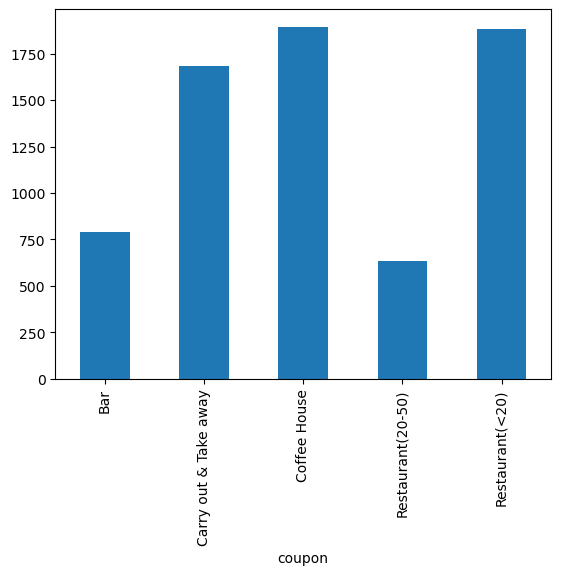

In [41]:
clean_data_no_nan.groupby('coupon')['Y'].sum().plot(kind = 'bar')

6. Use a histogram to visualize the temperature column.

<Axes: xlabel='temperature', ylabel='Count'>

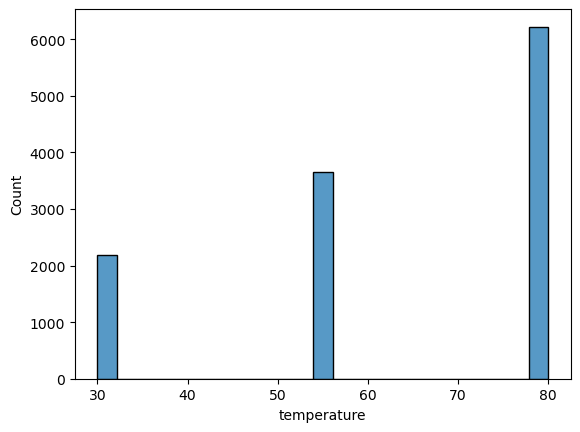

In [42]:
sns.histplot(data=clean_data_no_nan, x="temperature")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [43]:
bar_coupons = clean_data_no_nan[clean_data_no_nan['coupon'] == 'Bar']
bar_coupons.info() # 1913 rows

<class 'pandas.core.frame.DataFrame'>
Index: 1913 entries, 24 to 12682
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           1913 non-null   object
 1   passanger             1913 non-null   object
 2   weather               1913 non-null   object
 3   temperature           1913 non-null   int64 
 4   time                  1913 non-null   object
 5   coupon                1913 non-null   object
 6   expiration            1913 non-null   object
 7   gender                1913 non-null   object
 8   age                   1913 non-null   object
 9   maritalStatus         1913 non-null   object
 10  has_children          1913 non-null   int64 
 11  education             1913 non-null   object
 12  occupation            1913 non-null   object
 13  income                1913 non-null   object
 14  Bar                   1913 non-null   object
 15  CoffeeHouse           1913 non-null   obj

2. What proportion of bar coupons were accepted?


In [44]:
print(f"{bar_coupons['Y'].sum() / len(bar_coupons):0.2%}")


41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.

In [46]:
#bar_coupons['Bar'].unique()
#array(['never', 'less1', '1~3', 'gt8', nan, '4~8'], dtype=object)

bar_3_or_fewer = bar_coupons[bar_coupons['Bar'].isin(['never', 'less1', '1~3'])]
bar_4_or_more = bar_coupons[bar_coupons['Bar'].isin(['4~8', 'gt8'])]

acceptance_rate_3_or_more = bar_3_or_fewer['Y'].sum() / len(bar_3_or_fewer)
acceptance_rate_4_or_more = bar_4_or_more['Y'].sum() / len(bar_4_or_more)

print(f"Acceptance rate (bar 3 or fewer times): {acceptance_rate_3_or_more:.2%}")
print(f"Acceptance rate (bar 4 or more times): {acceptance_rate_4_or_more:.2%}")


Acceptance rate (bar 3 or fewer times): 37.27%
Acceptance rate (bar 4 or more times): 76.17%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?

**ANSWER**
1.   People who went the bar more than once a month are highly liekly to use a bar coupon with an acceptance rate of ~70% when they are over 21 years old.


```
  Over 25 and Bar > 1: 68.98%
  Under 25 and Bar > 1: 67.46%
  Under 21 and Bar > 1: 40.00% -- under 21 who has been to the bar in less likely to accept the bar coupon. This means most of high bar coupon acceptance comes from people who are over 21.  
```
2. People who are under 21 were 40% likely to accept the bar coupon regardless of whether they have been to bar or not.
```
  Under 21 and Bar < 1: 40.68%
  Under 21 and Bar > 1: 40.00%
```
3. People who goes to the bar less than once a month are less likely to accept the bar coupon regardless of the age. However, younger people are noticibly more likely to accept the bar coupon than older people.
```
  Over 25 and Bar < 1: 26.74%
  Under 25 and Bar < 1: 38.83%
```



In [47]:
# People who went the bar more than once a month are highly liekly to use a bar coupon with an acceptance rate of ~70% when they are over 21 years old.
#  Over 25 and Bar > 1: 68.98%
# Under 25 and Bar > 1: 67.46%
# Under 21 and Bar > 1: 40.00% -- under 21 who has been to the bar in less likely to accept the bar coupon. This means most of high bar coupon acceptance comes from people who are over 21.
#
#People who are under 21 were 40% likely to accept the bar coupon

#bar_coupons['Bar'].unique()
#array(['never', 'less1', '1~3', 'gt8', nan, '4~8'], dtype=object)

#bar_coupons['age'].unique()
#array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'], dtype=object)

drivers_over25_more_than_once = bar_coupons[(bar_coupons['Bar'].isin(['1~3', 'gt8', '4~8'])) & (bar_coupons['age'].isin(['46', '26', '31', '41', '50plus', '36']))]
acceptance_rate_over25_more_than_once = drivers_over25_more_than_once['Y'].sum() / len(drivers_over25_more_than_once)

drivers_over25_bar_less_than_1 = bar_coupons[(bar_coupons['Bar'].isin(['never', 'less1'])) & (bar_coupons['age'].isin(['46', '26', '31', '41', '50plus', '36']))]
acceptance_rate_over25_bar_less_than_1 = drivers_over25_bar_less_than_1['Y'].sum() / len(drivers_over25_bar_less_than_1)

drivers_under25 = bar_coupons[(bar_coupons['age'].isin(['21', 'below21']))]
acceptance_rate_under_25 = drivers_under25['Y'].sum() / len(drivers_under25)

drivers_under25_bar_less_than_1 = bar_coupons[(bar_coupons['Bar'].isin(['never', 'less1'])) & (bar_coupons['age'].isin(['21', 'below21']))]
acceptance_rate_under25_bar_less_than_1 = drivers_under25_bar_less_than_1['Y'].sum() / len(drivers_under25_bar_less_than_1)

drivers_under25_more_than_once = bar_coupons[(bar_coupons['Bar'].isin(['1~3', 'gt8', '4~8'])) & (bar_coupons['age'].isin(['21', 'below21']))]
acceptance_rate_under25_more_than_once = drivers_under25_more_than_once['Y'].sum() / len(drivers_under25_more_than_once)

drivers_under21_never = bar_coupons[(bar_coupons['Bar'].isin(['never'])) & (bar_coupons['age'].isin(['below21']))]
acceptance_rate_drivers_under21_never = drivers_under21_never['Y'].sum() / len(drivers_under21_never)

drivers_under21_more_than_once = bar_coupons[(bar_coupons['Bar'].isin(['1~3', 'gt8', '4~8'])) & (bar_coupons['age'].isin(['below21']))]
acceptance_rate_under21_more_than_once = drivers_under21_more_than_once['Y'].sum() / len(drivers_under21_more_than_once)

print(f"Over 25 and Bar > 1: {acceptance_rate_over25_more_than_once:.2%}")
print(f"Over 25 and Bar < 1: {acceptance_rate_over25_bar_less_than_1:.2%}")

print(f"Under 25: {acceptance_rate_under_25:.2%}")

print(f"Under 25 and Bar < 1: {acceptance_rate_under25_bar_less_than_1:.2%}")
print(f"Under 25 and Bar > 1: {acceptance_rate_under25_more_than_once:.2%}")

print(f"Under 21 and Bar < 1: {acceptance_rate_drivers_under21_never:.2%}")
print(f"Under 21 and Bar > 1: {acceptance_rate_under21_more_than_once:.2%}")

Over 25 and Bar > 1: 68.98%
Over 25 and Bar < 1: 26.74%
Under 25: 48.95%
Under 25 and Bar < 1: 38.83%
Under 25 and Bar > 1: 67.46%
Under 21 and Bar < 1: 40.68%
Under 21 and Bar > 1: 40.00%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.

**ANSWER**

1. Whether the driver visits bar regulary has the strongest influence on the bar coupon acceptance rate follow by having an adult passanger.
2. Whether the drive has a Farming, Fishing, & Forestry job does not influence the bar coupon acceptance rate much.

```
   Bar > 1: 68.53%
   Adult Passanger: 48.62%
   Adult Passengers & Bar > 1: 71.43%
   W/O Adult Passanger: 37.98%
   Not Farming, Fishing, Forestry: 41.18%
   Farming, Fishing, Forestry: 44.44%
```


In [48]:
drivers_bar_more_than_once = bar_coupons[(bar_coupons['Bar'].isin(['1~3', 'gt8', '4~8']))]
acceptance_rate_bar_more_than_once = drivers_bar_more_than_once['Y'].sum() / len(drivers_bar_more_than_once)
print(f"Bar > 1: {acceptance_rate_bar_more_than_once:.2%}")

drivers_adult_passangers_bar_more_than_once = bar_coupons[(bar_coupons['Bar'].isin(['1~3', 'gt8', '4~8'])) & (bar_coupons['passanger'].isin(['Friend(s)', 'Partner']))]
acceptance_rate_adult_passangers_bar_more_than_once = drivers_adult_passangers_bar_more_than_once['Y'].sum() / len(drivers_adult_passangers_bar_more_than_once)
print(f"Adult Passengers & Bar > 1: {acceptance_rate_adult_passangers_bar_more_than_once:.2%}")

#bar_coupons['passanger'].unique()
#array(['Friend(s)', 'Alone', 'Kid(s)', 'Partner'], dtype=object)
drivers_adult_passengers = bar_coupons[(bar_coupons['passanger'].isin(['Friend(s)', 'Partner']))]
acceptance_rate_adult_passengers = drivers_adult_passengers['Y'].sum() / len(drivers_adult_passengers)
print(f"Adult Passanger: {acceptance_rate_adult_passengers:.2%}")

drivers_WO_adult_passengers = bar_coupons[(~bar_coupons['passanger'].isin(['Friend(s)', 'Partner']))]
acceptance_rate_WO_adult_passengers = drivers_WO_adult_passengers['Y'].sum() / len(drivers_WO_adult_passengers)
print(f"W/O Adult Passanger: {acceptance_rate_WO_adult_passengers:.2%}")

#bar_coupons['occupation'].unique()
drivers_not_farming_fishing_forestry = bar_coupons[~bar_coupons['occupation'].isin(['Farming Fishing & Forestry'])]
acceptance_rate_not_farming_fishing_forestry = drivers_not_farming_fishing_forestry['Y'].sum() / len(drivers_not_farming_fishing_forestry)
print(f"Not Farming, Fishing, Forestry: {acceptance_rate_not_farming_fishing_forestry:.2%}")

drivers_farming_fishing_forestry = bar_coupons[bar_coupons['occupation'].isin(['Farming Fishing & Forestry'])]
acceptance_rate_farming_fishing_forestry = drivers_farming_fishing_forestry['Y'].sum() / len(drivers_farming_fishing_forestry)
print(f"Farming, Fishing, Forestry: {acceptance_rate_farming_fishing_forestry:.2%}")


Bar > 1: 68.53%
Adult Passengers & Bar > 1: 71.43%
Adult Passanger: 48.62%
W/O Adult Passanger: 37.98%
Not Farming, Fishing, Forestry: 41.18%
Farming, Fishing, Forestry: 44.44%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.

**ANSWER**

1. Not widowed drivers with adult passenger who goes to bars more than once a month are most likely to accept the bar coupons.
2. In general, drivers who go to bars more than once a monthly are highly likely to accept the bar coupon.
3. Driver who frequent cheap restaurants with income less than $50k are less likely to accept the bar coupons.
```
Bar > 1, Adult Passanger, Not Widowed: 71.43%
Bar > 1, Under 30: 67.46%
Cheap Restaurant, Income < 50K: 45.65%
```



In [49]:
#bar_coupons['maritalStatus'].unique()
#array(['Single', 'Married partner', 'Unmarried partner', 'Divorced','Widowed'], dtype=object)

bar_more_than_once_adult_passenger_not_widowed = bar_coupons[(bar_coupons['Bar'].isin(['1~3', 'gt8', '4~8']))
& (bar_coupons['passanger'].isin(['Friend(s)', 'Partner']))
& (bar_coupons['maritalStatus'].isin(['Single', 'Married partner', 'Unmarried partner', 'Divorced']))]
acceptance_rate_moreThanOnce_adultP_NotWidowed = bar_more_than_once_adult_passenger_not_widowed['Y'].sum() / len(bar_more_than_once_adult_passenger_not_widowed)
print(f"Bar > 1, Adult Passanger, Not Widowed: {acceptance_rate_moreThanOnce_adultP_NotWidowed:.2%}")

#bar_coupons['age'].unique()
#array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'], dtype=object)
bar_more_than_once_under_30 = bar_coupons[(bar_coupons['Bar'].isin(['1~3', 'gt8', '4~8'])) & (bar_coupons['age'].isin(['21', 'below21']))]
acceptance_rate_bar_more_than_once_under_30 = bar_more_than_once_under_30['Y'].sum() / len(bar_more_than_once_under_30)
print(f"Bar > 1, Under 30: {acceptance_rate_bar_more_than_once_under_30:.2%}")

#bar_coupons['RestaurantLessThan20'].unique()
#array(['4~8', '1~3', 'less1', 'gt8', 'never'], dtype=object)
#bar_coupons['income'].unique()
restaurant_cheap_restaurant_income_less_than_50 = bar_coupons[(bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8']))
& (bar_coupons['income'].isin(['$12500 - $24999', '$37500 - $49999', '$25000 - $37499', 'Less than $12500']))]
acceptance_rate_estaurant_cheap_restaurant_income_less_than_50 = restaurant_cheap_restaurant_income_less_than_50['Y'].sum() / len(restaurant_cheap_restaurant_income_less_than_50)
print(f"Cheap Restaurant, Income < 50K: {acceptance_rate_estaurant_cheap_restaurant_income_less_than_50:.2%}")


Bar > 1, Adult Passanger, Not Widowed: 71.43%
Bar > 1, Under 30: 67.46%
Cheap Restaurant, Income < 50K: 45.65%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

**ANSWER**
1. The driver who goes to bar regularly is the strongest driver raising the bar coupon acceptance rate.
```
    Acceptance rate (bar 3 or fewer times): 37.27%
     Acceptance rate (bar 4 or more times): 76.17%
```
2. Driver over 21 who goes to the bar have higher acceptance rate.
```
  Over 25 and Bar > 1: 68.98%
  Under 25 and Bar > 1: 67.46%
  Under 21 and Bar > 1: 40.00%
```
3. Having an adult passenger increases coupon acceptance rate by ~10%
```
        Adult Passanger: 48.62%
    W/O Adult Passanger: 37.98%
```
4. Job types doesn't seem to make much difference
```
  Not Farming, Fishing, Forestry: 41.18%
      Farming, Fishing, Forestry: 44.44%
```

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [50]:
#clean_data_no_nan['coupon'].unique()
#array(['Restaurant(<20)', 'Coffee House', 'Carry out & Take away', 'Bar','Restaurant(20-50)'], dtype=object)
coffee_coupons = clean_data_no_nan[clean_data_no_nan['coupon'] == 'Coffee House']
coffee_coupons.info() # 3816 rows

<class 'pandas.core.frame.DataFrame'>
Index: 3816 entries, 23 to 12681
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           3816 non-null   object
 1   passanger             3816 non-null   object
 2   weather               3816 non-null   object
 3   temperature           3816 non-null   int64 
 4   time                  3816 non-null   object
 5   coupon                3816 non-null   object
 6   expiration            3816 non-null   object
 7   gender                3816 non-null   object
 8   age                   3816 non-null   object
 9   maritalStatus         3816 non-null   object
 10  has_children          3816 non-null   int64 
 11  education             3816 non-null   object
 12  occupation            3816 non-null   object
 13  income                3816 non-null   object
 14  Bar                   3816 non-null   object
 15  CoffeeHouse           3816 non-null   obj

<Axes: xlabel='time'>

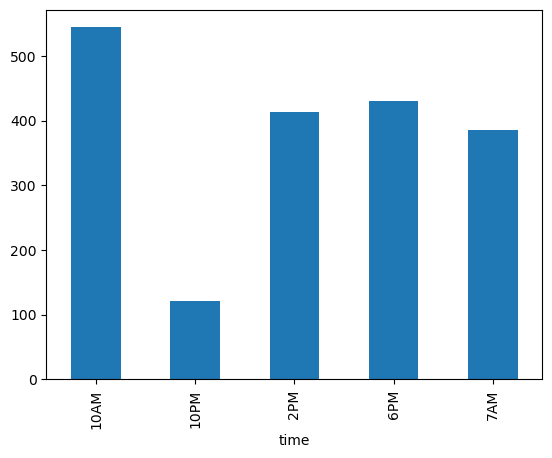

In [51]:
# Drivers accept coffee coupons through the day accept at late night.
coffee_coupons.groupby('time')['Y'].sum().plot(kind = 'bar')


<Axes: xlabel='weather', ylabel='Count'>

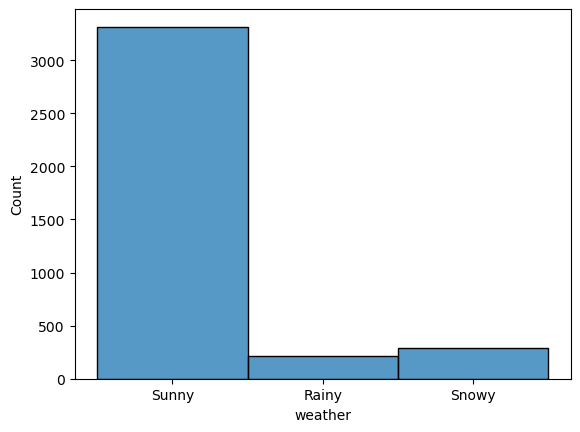

In [52]:
sns.histplot(data=coffee_coupons, x="weather")

In [54]:

# Coffee acceptance rate is highest before 2PM

#coffee_coupons['time'].unique()
#array(['10AM', '2PM', '6PM', '7AM', '10PM'], dtype=object)

coffee_morning = coffee_coupons[(coffee_coupons['time'].isin(['10AM', '7AM']))]
acceptance_rate_coffee_morning = coffee_morning['Y'].sum() / len(coffee_morning)
print(f"Morning: {acceptance_rate_coffee_morning:.2%}")

coffee_2pm = coffee_coupons[(coffee_coupons['time'].isin(['2PM']))]
acceptance_rate_coffee_2pm = coffee_2pm['Y'].sum() / len(coffee_2pm)
print(f"2PM: {acceptance_rate_coffee_2pm:.2%}")

coffee_afternoon = coffee_coupons[(coffee_coupons['time'].isin(['2PM','6PM']))]
acceptance_rate_coffee_afternoon = coffee_afternoon['Y'].sum() / len(coffee_afternoon)
print(f"Afternoon: {acceptance_rate_coffee_afternoon:.2%}")

coffee_10PM = coffee_coupons[(coffee_coupons['time'].isin(['10PM']))]
acceptance_rate_coffee_10PM = coffee_10PM['Y'].sum() / len(coffee_10PM)
print(f"10PM: {acceptance_rate_coffee_10PM:.2%}")

Morning: 53.64%
2PM: 54.55%
Afternoon: 46.84%
10PM: 42.91%


<Axes: xlabel='income'>

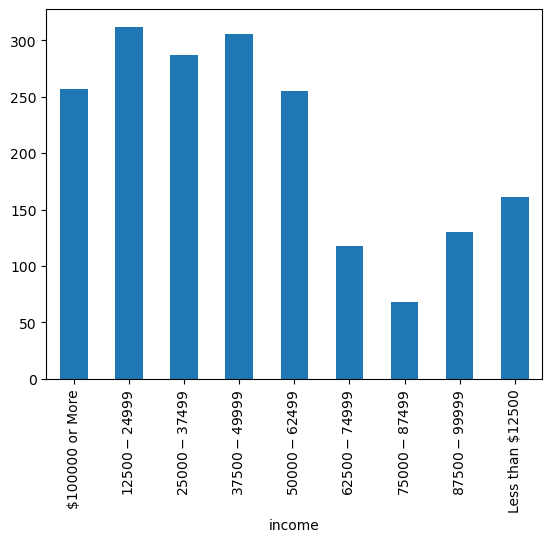

In [55]:
# Drivers with income less below $62,500 accepted most coupons
coffee_coupons.groupby('income')['Y'].sum().plot(kind = 'bar')

In [56]:
#High income driver's coffee coupon acceptance rate is bit lower much not by much.

#coffee_coupons['income'].unique()
#array(['Less than $12500', '$12500 - $24999', '$25000 - $37499',
#       '$37500 - $49999','$50000 - $62499', '$62500 - $74999',
#       '$75000 - $87499','$87500 - $99999', '$100000 or More']     dtype=object)
coffee_less_37500 = coffee_coupons[(coffee_coupons['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499']))]
acceptance_rate_coffee_less_37500 = coffee_less_37500['Y'].sum() / len(coffee_less_37500)
print(f"Income < $37,500: {acceptance_rate_coffee_less_37500:.2%}")

coffee_37500_and_74999 = coffee_coupons[(coffee_coupons['income'].isin(['$37500 - $49999','$50000 - $62499', '$62500 - $74999']))]
acceptance_rate_coffee_37500_and_74999 = coffee_37500_and_74999['Y'].sum() / len(coffee_37500_and_74999)
print(f"Income between $37,500 & $74,999: {acceptance_rate_coffee_37500_and_74999:.2%}")

coffee_greater_75000 = coffee_coupons[(coffee_coupons['income'].isin(['$75000 - $87499','$87500 - $99999', '$100000 or More']))]
acceptance_rate_coffee_greater_75000 = coffee_greater_75000['Y'].sum() / len(coffee_greater_75000)
print(f"Income greater than $75,000: {acceptance_rate_coffee_greater_75000:.2%}")


Income < $37,500: 51.35%
Income between $37,500 & $74,999: 50.60%
Income greater than $75,000: 45.77%


In [57]:
# Acceptance rate a bit higher when with an adult passanger

#coffee_coupons['passanger'].unique()
#array(['Friend(s)', 'Alone', 'Kid(s)', 'Partner'], dtype=object)

coffee_alone = coffee_coupons[(coffee_coupons['passanger'].isin(['Alone']))]
acceptance_rate_coffee_alone = coffee_alone['Y'].sum() / len(coffee_alone)
print(f"Alone: {acceptance_rate_coffee_alone:.2%}")

coffee_not_alone = coffee_coupons[(~coffee_coupons['passanger'].isin(['Alone']))]
acceptance_rate_coffee_not_alone = coffee_not_alone['Y'].sum() / len(coffee_not_alone)
print(f"Not Alone: {acceptance_rate_coffee_not_alone:.2%}")

coffee_kids = coffee_coupons[(coffee_coupons['passanger'].isin(['Kid(s)']))]
acceptance_rate_coffee_kids = coffee_kids['Y'].sum() / len(coffee_kids)
print(f"With Kids: {acceptance_rate_coffee_kids:.2%}")

coffee_adult = coffee_coupons[(coffee_coupons['passanger'].isin(['Friend(s)','Partner']))]
acceptance_rate_coffee_adult = coffee_adult['Y'].sum() / len(coffee_adult)
print(f"Adult Passenger: {acceptance_rate_coffee_adult:.2%}")


Alone: 43.39%
Not Alone: 57.75%
With Kids: 47.15%
Adult Passenger: 59.14%


In [58]:
# More likely to accept coffee coupons on Sunny and Rainy days

#coffee_coupons['weather'].unique()
#array(['Sunny', 'Rainy', 'Snowy'], dtype=object)

coffee_sunny = coffee_coupons[(coffee_coupons['weather'].isin(['Sunny']))]
acceptance_rate_coffee_sunny = coffee_sunny['Y'].sum() / len(coffee_sunny)
print(f"Sunny: {acceptance_rate_coffee_sunny:.2%}")

coffee_rainy = coffee_coupons[(coffee_coupons['weather'].isin(['Rainy']))]
acceptance_rate_coffee_rainy = coffee_rainy['Y'].sum() / len(coffee_rainy)
print(f"Rainy: {acceptance_rate_coffee_rainy:.2%}")

coffee_snowy = coffee_coupons[(coffee_coupons['weather'].isin(['Snowy']))]
acceptance_rate_coffee_snowy = coffee_snowy['Y'].sum() / len(coffee_snowy)
print(f"Snowy: {acceptance_rate_coffee_snowy:.2%}")



Sunny: 50.09%
Rainy: 51.63%
Snowy: 42.81%


In [59]:
# Coffee acceptance rate is higher as temperature increases.

#coffee_coupons['temperature'].unique()
#array([80, 55, 30])
coffee_30 = coffee_coupons[(coffee_coupons['temperature'] == 30)]
acceptance_rate_coffee_30 = coffee_30['Y'].sum() / len(coffee_30)
print(f"30 Deg: {acceptance_rate_coffee_30:.2%}")

coffee_55 = coffee_coupons[(coffee_coupons['temperature'] == 55)]
acceptance_rate_coffee_55 = coffee_55['Y'].sum() / len(coffee_55)
print(f"55 Deg: {acceptance_rate_coffee_55:.2%}")

coffee_80 = coffee_coupons[(coffee_coupons['temperature'] == 80)]
acceptance_rate_coffee_80 = coffee_80['Y'].sum() / len(coffee_80)
print(f"80 Deg: {acceptance_rate_coffee_80:.2%}")



30 Deg: 44.15%
55 Deg: 45.20%
80 Deg: 52.70%


In [60]:
# Combining three attributes (Sunny & Rainy + Adult Passenger + Time) didn't do much better than using one attribute (adult passenger)
# Adult Passenger: 59.14%

coffee_high_acceptance = coffee_coupons[
 (coffee_coupons['weather'].isin(['Sunny','Rainy']))
& (coffee_coupons['passanger'].isin(['Friend(s)','Partner']))
& (coffee_coupons['time'].isin(['10AM', '7AM', '2PM']))]
#print(coffee_high_acceptance['Y'].sum())
acceptance_rate_high = coffee_high_acceptance['Y'].sum() / len(coffee_high_acceptance)
print(f"Sunny & Rainy + Adult Passenger + Time: {acceptance_rate_high:.2%}")

#coffee_coupons[(coffee_coupons['temperature'] == 30)


Sunny & Rainy + Adult Passenger + Time: 59.29%
